In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import CenteredNorm
from openpmd_viewer import OpenPMDTimeSeries

plt.rcParams["font.size"] = 14

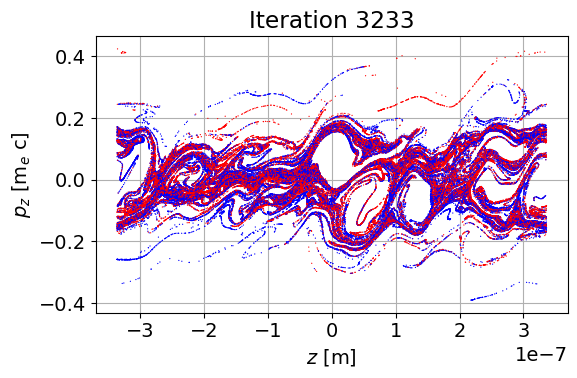

In [2]:
series = OpenPMDTimeSeries("diags/particles/")
iterations = series.iterations

for i in iterations[-1:]:
    fig, ax = plt.subplots(figsize=(6, 4))
    x1, z1, w1 = series.get_particle(["uz", "z", "w"], iteration=i, species="ele1")
    x2, z2, w2 = series.get_particle(["uz", "z", "w"], iteration=i, species="ele2")

    x = np.append(x1, x2)
    z = np.append(z1, z2)
    w = np.append(w1, -w2)

    indices = np.random.permutation(len(w))

    x = x[indices]
    z = z[indices]
    w = w[indices]

    ax.scatter(z, x, s=0.8, c=w, linewidths=0, cmap="bwr", zorder=10)

    ax.set_xlabel(r"$z$ [m]")
    ax.set_ylabel(r"$p_z$ [m$_e$ c]")
    ax.set_title(f"Iteration {i}")
    ax.grid(True, zorder=1)
    fig.tight_layout()

plt.show()

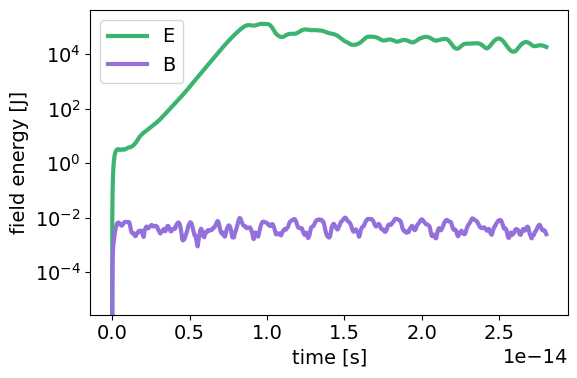

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

FE = pd.read_csv("diags/reducedfiles/FieldEnergy.txt", sep=" ", header=0)
times = FE[[col for col in FE.columns if f"]time" in col]].to_numpy()
E_energy = FE[[col for col in FE.columns if f"]E_" in col]].to_numpy()
B_energy = FE[[col for col in FE.columns if f"]B_" in col]].to_numpy()

ax.semilogy(times, E_energy, lw=3, color="mediumseagreen", label="E")
ax.semilogy(times, B_energy, lw=3, color="mediumpurple", label="B")

ax.legend()
ax.set_xlabel("time [s]")
ax.set_ylabel("field energy [J]")
fig.tight_layout()
plt.show()